In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [2]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final4_2.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [3]:
# 데이터를 읽어온다.
train_df = pd.read_csv('train_VIF.csv')
test_df = pd.read_csv('test_VIF.csv')

display(train_df)
display(test_df)

,소지카드수_이용가능_신용,소지카드수_유효_신용,이용가능여부_해외겸용_본인,수신거부여부_TM,이용금액_R3M_신용체크,이용카드수_신용체크,_2순위카드이용금액,상향가능한도금액,상향가능CA한도금액,정상청구원금_B5M,...,최대이용금액_일시불_R12M,_1순위교통업종_이용금액,연체입금원금_B0M,쇼핑_슈퍼마켓_이용금액,_1순위쇼핑업종_이용금액,연속유실적개월수_기본_24M_카드,이용금액대,할인건수_R3M,잔액_일시불_B0M,인입횟수_ARS_R6M
0,1,1,0,0,196,1,0,0,0,14958,...,4906,200,8104,0,242,13,01.100만원+,1회 이상,998,10회 이상
1,1,1,0,0,13475,1,0,4,1,3367,...,10407,1215,826,435,645,12,03.30만원+,1회 이상,2565,1회 이상
2,1,1,1,0,23988,1,0,0,0,23963,...,10112,1362,9364,504,6094,8,01.100만원+,1회 이상,5312,1회 이상
3,2,2,1,0,3904,1,0,0,0,19614,...,3075,208,10923,487,801,5,01.100만원+,1회 이상,730,10회 이상
4,1,1,1,0,1190,1,0,0,0,0,...,62,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,1,1,1,0,10755,1,0,3,1,0,...,0,0,19,0,0,0,09.미사용,1회 이상,0,1회 이상
2399996,1,1,1,0,27636,1,0,10,3,23742,...,47684,632,3756,714,1496,17,01.100만원+,1회 이상,3351,1회 이상
2399997,1,1,1,1,23187,1,0,0,0,4125,...,10212,1925,1703,400,1458,24,02.50만원+,1회 이상,2524,1회 이상
2399998,1,1,0,1,0,0,0,4,1,507,...,0,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상


,소지카드수_이용가능_신용,소지카드수_유효_신용,이용가능여부_해외겸용_본인,수신거부여부_TM,이용금액_R3M_신용체크,이용카드수_신용체크,_2순위카드이용금액,상향가능한도금액,상향가능CA한도금액,정상청구원금_B5M,...,최대이용금액_일시불_R12M,_1순위교통업종_이용금액,연체입금원금_B0M,쇼핑_슈퍼마켓_이용금액,_1순위쇼핑업종_이용금액,연속유실적개월수_기본_24M_카드,이용금액대,할인건수_R3M,잔액_일시불_B0M,인입횟수_ARS_R6M
0,2,2,1,1,21458,2,6021,7,2,3919,...,21700,1204,2814,350,1393,5,02.50만원+,1회 이상,4802,1회 이상
1,1,1,1,0,18681,2,0,0,0,5723,...,2423,1278,918,0,4463,8,02.50만원+,1회 이상,1201,1회 이상
2,2,2,0,0,40758,2,10704,0,0,11267,...,12667,2022,222,1094,1679,24,01.100만원+,1회 이상,3046,1회 이상
3,1,1,1,0,5255,1,0,3,1,0,...,1661,1419,0,634,824,5,04.10만원+,1회 이상,768,1회 이상
4,1,1,1,1,16148,3,6387,2,0,1347,...,1082,527,0,323,890,20,03.30만원+,1회 이상,637,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
599996,1,1,0,0,3110,1,0,8,2,992,...,1067,0,0,0,0,8,05.10만원-,1회 이상,191,1회 이상
599997,1,1,0,0,0,0,0,5,1,0,...,0,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
599998,3,3,1,1,173263,6,31916,9,2,27335,...,64459,2584,16746,848,50074,24,01.100만원+,1회 이상,17916,1회 이상


In [6]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [7]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,소지카드수_이용가능_신용,소지카드수_유효_신용,이용가능여부_해외겸용_본인,수신거부여부_TM,이용금액_R3M_신용체크,이용카드수_신용체크,_2순위카드이용금액,상향가능한도금액,상향가능CA한도금액,정상청구원금_B5M,...,최대이용금액_일시불_R12M,_1순위교통업종_이용금액,연체입금원금_B0M,쇼핑_슈퍼마켓_이용금액,_1순위쇼핑업종_이용금액,연속유실적개월수_기본_24M_카드,이용금액대,할인건수_R3M,잔액_일시불_B0M,인입횟수_ARS_R6M
0,1,1,0,0,196,1,0,0,0,14958,...,4906,200,8104,0,242,13,01.100만원+,1회 이상,998,10회 이상
1,1,1,0,0,13475,1,0,4,1,3367,...,10407,1215,826,435,645,12,03.30만원+,1회 이상,2565,1회 이상
2,1,1,1,0,23988,1,0,0,0,23963,...,10112,1362,9364,504,6094,8,01.100만원+,1회 이상,5312,1회 이상
3,2,2,1,0,3904,1,0,0,0,19614,...,3075,208,10923,487,801,5,01.100만원+,1회 이상,730,10회 이상
4,1,1,1,0,1190,1,0,0,0,0,...,62,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
2999996,1,1,0,0,3110,1,0,8,2,992,...,1067,0,0,0,0,8,05.10만원-,1회 이상,191,1회 이상
2999997,1,1,0,0,0,0,0,5,1,0,...,0,0,0,0,0,0,09.미사용,1회 이상,0,1회 이상
2999998,3,3,1,1,173263,6,31916,9,2,27335,...,64459,2584,16746,848,50074,24,01.100만원+,1회 이상,17916,1회 이상


In [5]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   소지카드수_이용가능_신용       int64 
 1   소지카드수_유효_신용         int64 
 2   이용가능여부_해외겸용_본인      int64 
 3   수신거부여부_TM           int64 
 4   이용금액_R3M_신용체크       int64 
 5   이용카드수_신용체크          int64 
 6   _2순위카드이용금액          int64 
 7   상향가능한도금액            int64 
 8   상향가능CA한도금액          int64 
 9   정상청구원금_B5M          int64 
 10  이용건수_신용_R12M        int64 
 11  최대이용금액_일시불_R12M     int64 
 12  _1순위교통업종_이용금액       int64 
 13  연체입금원금_B0M          int64 
 14  쇼핑_슈퍼마켓_이용금액        int64 
 15  _1순위쇼핑업종_이용금액       int64 
 16  연속유실적개월수_기본_24M_카드  int64 
 17  이용금액대               object
 18  할인건수_R3M            object
 19  잔액_일시불_B0M          int64 
 20  인입횟수_ARS_R6M        object
dtypes: int64(18), object(3)
memory usage: 480.7+ MB


In [8]:
# LabelEncoder 학습
Endoder1 = LabelEncoder()
Endoder2 = LabelEncoder()
Endoder3 = LabelEncoder()

Endoder1.fit(all_df['이용금액대'])
Endoder2.fit(all_df['할인건수_R3M'])
Endoder3.fit(all_df['인입횟수_ARS_R6M'])

LabelEncoder()

In [9]:
train_df['이용금액대'] = Endoder1.transform(train_df['이용금액대'])
train_df['할인건수_R3M'] = Endoder2.transform(train_df['할인건수_R3M'])
train_df['인입횟수_ARS_R6M'] = Endoder3.transform(train_df['인입횟수_ARS_R6M'])

In [10]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(train_df)

,copy,True
,with_mean,True
,with_std,True


In [11]:
train_data['이용금액대'] = Endoder1.transform(train_data['이용금액대'])
train_data['할인건수_R3M'] = Endoder2.transform(train_data['할인건수_R3M'])
train_data['인입횟수_ARS_R6M'] = Endoder3.transform(train_data['인입횟수_ARS_R6M'])

In [12]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [13]:
tg_df = pd.concat([
    target1['Segment'],
    target2['Segment'],
    target3['Segment'],
    target4['Segment'],
    target5['Segment'],
    target6['Segment']
])

tg_df = tg_df.reset_index(drop=True).to_frame(name='Segment')
tg_df

,Segment
0,D
1,E
2,C
3,D
4,E
...,...
2399995,E
2399996,D
2399997,C
2399998,E


In [14]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
tg_df['Segment'] = le.fit_transform(tg_df['Segment'])

In [15]:
tg_df2=tg_df.copy()

y_train = tg_df2.loc[train_data.index]
y_val = tg_df2.loc[val_data.index]

In [16]:
# 입력과 결과로 나눈다.
X=train_data
y=y_train

In [17]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-0.24668788, -0.43451382,  0.57132578, ...,  0.15688958,
        -0.41106837,  0.17468495],
       [-1.85886015, -0.43451382,  0.57132578, ...,  0.15688958,
        -0.51390045,  0.17468495],
       [ 1.36548438,  1.32995257,  0.57132578, ...,  3.11010526,
         0.31902386,  0.17468495],
       ...,
       [-0.24668788, -0.43451382,  0.57132578, ...,  0.15688958,
        -0.25051964,  0.17468495],
       [ 1.36548438,  1.32995257,  0.57132578, ..., -2.7963261 ,
        -0.12839682,  0.17468495],
       [-0.24668788, -0.43451382,  0.57132578, ...,  0.15688958,
        -0.48963146,  0.17468495]])

In [18]:
train_X = X2
train_y = y

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [19]:
model5 = LGBMClassifier(device='cpu', objective='multiclass', num_class=5, verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
r1 = cross_val_score(model5, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

f1_score_list.append(r1.mean())
model_name_list.append("LGBMClassifier")

평균 f1 Score : 0.8688348958333334


In [20]:
# CPU 기반 XGBoost 모델
model6 = XGBClassifier(
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# f1_weighted 사용
r2 = cross_val_score(model6, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r2.mean():.4f}')

f1_score_list.append(r2.mean())
model_name_list.append("XGBClassifier")

평균 f1 Score : 0.8774


In [56]:
import pandas as pd

# 결과를 DataFrame으로 묶기
result_df = pd.DataFrame({
    'Model': model_name_list,
    'F1_Score': f1_score_list
})

# CSV로 저장
result_df.to_csv('data/model_f1_scores4.csv', index=False)

In [21]:
df = pd.DataFrame({
    'Model': model_name_list,
    'f1 score': f1_score_list
})
df = df.dropna()

In [22]:
df

,Model,f1 score
0,LGBMClassifier,0.868835
1,XGBClassifier,0.877394


In [23]:
final_model=model6.fit(train_X, train_y)

In [24]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(model6, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(Endoder1, fp)
    pickle.dump(Endoder2, fp)
    pickle.dump(Endoder3, fp)
    pickle.dump(le, fp)  # ← LabelEncoder 객체 추가

print('저장완료')

저장완료


In [25]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final4_2.dat'

In [26]:
with open(best_model_path, 'rb') as fp :
    best_model = pickle.load(fp)
    scalerX = pickle.load(fp)
    Endoder1 = pickle.load(fp)
    Endoder2 = pickle.load(fp)
    Endoder3 = pickle.load(fp)
    SegmentEncoder = pickle.load(fp)

display(best_model)
display(scalerX)
display(Endoder1)
display(Endoder2)
display(Endoder3)
display(SegmentEncoder)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


,copy,True
,with_mean,True
,with_std,True


LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

In [27]:
val_data['이용금액대'] = Endoder1.transform(val_data['이용금액대'])
val_data['할인건수_R3M'] = Endoder2.transform(val_data['할인건수_R3M'])
val_data['인입횟수_ARS_R6M'] = Endoder3.transform(val_data['인입횟수_ARS_R6M'])

In [28]:
mat_X = val_data
mat_y = y_val

In [29]:
y_train_encoded = SegmentEncoder.fit_transform(mat_y)

In [30]:
y_pred_train = model6.predict(mat_X)

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [32]:
y_train_encoded

array([4, 4, 4, ..., 4, 3, 4])

In [33]:
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

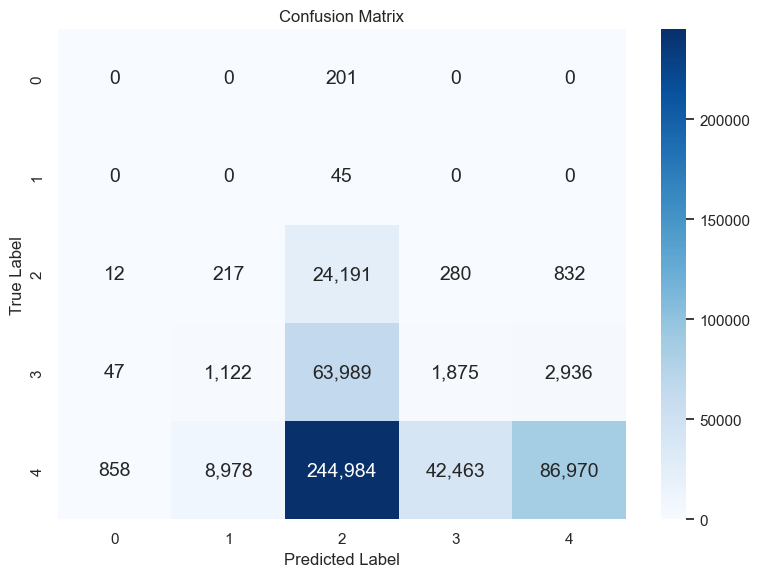

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 역변환
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

# 안전하게 라벨 추출
labels = list(np.unique(y_true_labels))

# 혼동 행렬
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

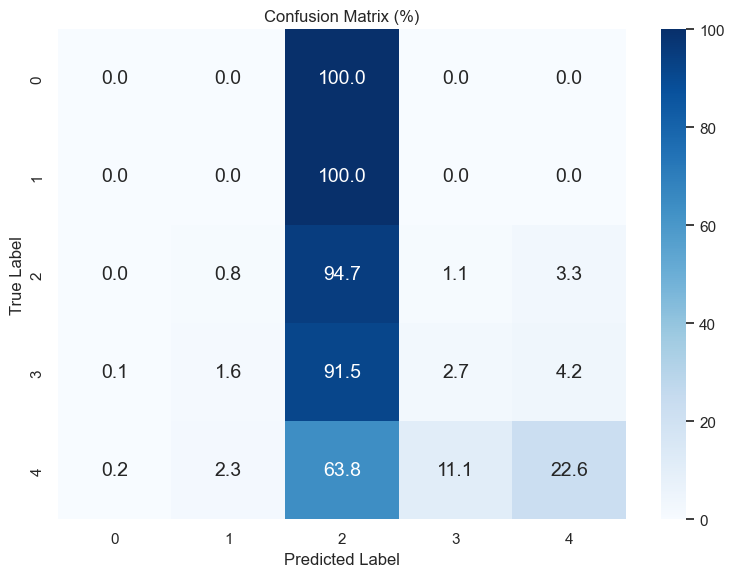

In [35]:
# 비율 기준 혼동행렬 계산
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

cm_percent_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent_df, annot=True, fmt=".1f", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (%)")
plt.tight_layout()
plt.show()
